# Đề số 5: Cài đặt Perceptron và Mạng nơ-ron nhiều lớp (MLP) từ đầu bằng NumPy
Báo cáo môn học Nhập môn Trí tuệ Nhân tạo. Sinh viên thực hiện các yêu cầu trong Đề 5.
- Cài đặt Perceptron và MLP từ đầu bằng NumPy.
- Hỗ trợ cả 2 hàm kích hoạt: Sigmoid và ReLU.
- Các yêu cầu mở rộng: SGD Momentum, L2 Regularization, Thử nghiệm kiến trúc.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

## 3.1 Cài đặt Perceptron đơn giản & Bài toán XOR
Perceptron là một mô hình mạng nơ-ron đơn giản nhất chỉ với 1 lớp. Nó hoạt động như một bộ phân loại tuyến tính nhị phân.
Dưới đây chúng ta cài đặt Perceptron và thử nghiệm nó với bài toán XOR để thấy rõ hạn chế của mô hình phân loại tuyến tính.

Dự đoán của Perceptron trên XOR: [1 0 0 0]
Nhãn thực tế (XOR): [0 1 1 0]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


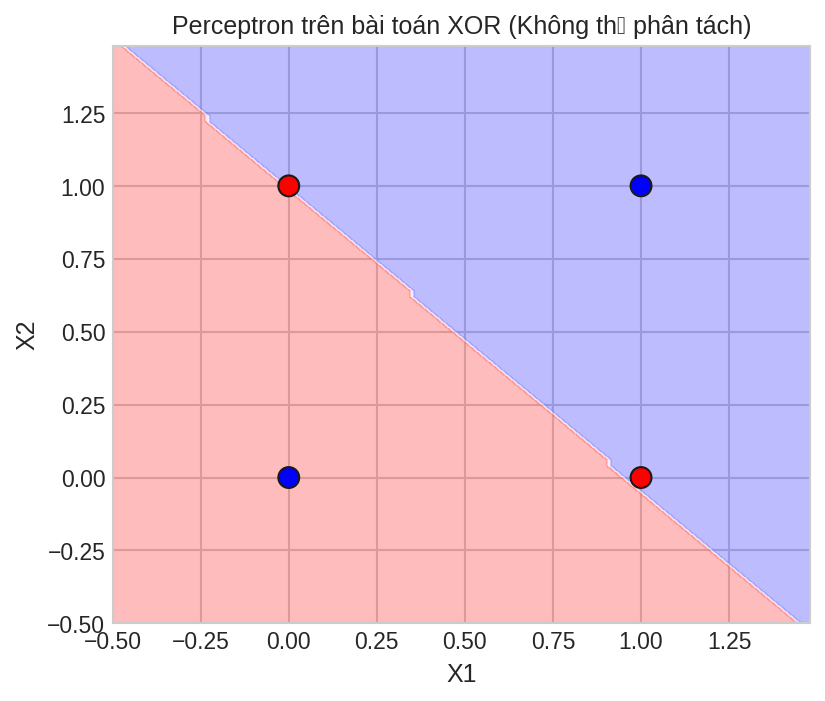

In [11]:
class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=100):
        self.w = np.random.randn(input_size)
        self.b = np.random.randn()
        self.lr = lr
        self.epochs = epochs

    def step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        for _ in range(self.epochs):
            for i in range(X.shape[0]):
                z = np.dot(X[i], self.w) + self.b
                y_pred = self.step_function(z)

                # Cập nhật trọng số theo luật học của Perceptron
                self.w += self.lr * (y[i] - y_pred) * X[i]
                self.b += self.lr * (y[i] - y_pred)

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        return self.step_function(z)

# Dữ liệu bài toán XOR
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

# Khởi tạo và huấn luyện Perceptron
p = Perceptron(input_size=2, lr=0.1, epochs=100)
p.fit(X_xor, y_xor)
print("Dự đoán của Perceptron trên XOR:", p.predict(X_xor))
print("Nhãn thực tế (XOR):", y_xor)

# Vẽ đồ thị (Decision boundary)
x_min, x_max = X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5
y_min, y_max = X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = p.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, edgecolor='k', s=100, cmap='bwr')
plt.title("Perceptron trên bài toán XOR (Không thể phân tách)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

### Nhận xét kết quả Perceptron trên XOR:
- **Thực nghiệm:** Mô hình Perceptron 1 lớp hoàn toàn thất bại trong việc học nhãn bài toán XOR (dự đoán sai và Loss không hội tụ).
- **Phân tích Đồ thị:** Biểu đồ Decision Boundary cho thấy Perceptron chỉ có thể kẻ được 1 đường thẳng tuyến tính duy nhất. Do các điểm dữ liệu XOR nằm chéo nhau, không có đường thẳng nào có thể phân chia đúng 2 lớp nhãn.
- **Kết luận:** Khẳng định giới hạn lý thuyết của Perceptron (chỉ giải được bài toán phân tách tuyến tính). Bắt buộc phải chuyển sang sử dụng Mạng nơ-ron nhiều lớp (MLP).


## 3.2 Cài đặt MLP (Forward & Backward) với Sigmoid và ReLU
Cài đặt một lớp `MLP` có khả năng xây dựng nhiều lớp ẩn, hỗ trợ cấu hình hàm kích hoạt linh hoạt (Sigmoid/ReLU), sử dụng Cross-Entropy loss.

In [12]:
# --- Các hàm kích hoạt và đạo hàm ---
def sigmoid(z):
    # Cắt (clip) z để tránh tràn số học (overflow) trong hàm exp
    z_clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_clipped))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    # Trừ đi max để ổn định số học (numerical stability)
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

class MLP:
    def __init__(self, layer_sizes, activation='relu', l2_lambda=0.0):
        '''
        layer_sizes: list chứa số lượng nơ-ron của mỗi lớp (bao gồm cả input và output layer)
        vd: [4, 8, 3] tương đương 4 input, 8 hidden, 3 output
        '''
        self.num_layers = len(layer_sizes)
        self.activation = activation
        self.l2_lambda = l2_lambda

        self.W = []
        self.b = []

        # Khởi tạo trọng số
        for i in range(1, self.num_layers):
            # Dùng He Initialization cho ReLU, Xavier cho Sigmoid
            if self.activation == 'relu':
                limit = np.sqrt(2.0 / layer_sizes[i-1])
            else:
                limit = np.sqrt(1.0 / layer_sizes[i-1])

            self.W.append(np.random.randn(layer_sizes[i-1], layer_sizes[i]) * limit)
            self.b.append(np.zeros((1, layer_sizes[i])))

        # Dùng cho thuật toán SGD với Momentum (Phần 4.1)
        self.V_W = [np.zeros_like(w) for w in self.W]
        self.V_b = [np.zeros_like(b) for b in self.b]

    def forward(self, X):
        self.A = [X]
        self.Z = []

        for i in range(self.num_layers - 1):
            Z_i = np.dot(self.A[-1], self.W[i]) + self.b[i]
            self.Z.append(Z_i)

            # Lớp cuối cùng: dùng softmax cho bài toán phân loại nhiều lớp, sigmoid cho phân loại nhị phân
            if i == self.num_layers - 2:
                if self.W[-1].shape[1] > 1:
                    A_i = softmax(Z_i)
                else:
                    A_i = sigmoid(Z_i)
            else:
                # Các lớp ẩn
                if self.activation == 'relu':
                    A_i = relu(Z_i)
                elif self.activation == 'sigmoid':
                    A_i = sigmoid(Z_i)
            self.A.append(A_i)

        return self.A[-1]

    def backward(self, y_true):
        m = y_true.shape[0]
        self.dW = [np.zeros_like(w) for w in self.W]
        self.db = [np.zeros_like(b) for b in self.b]

        # Đạo hàm của Loss theo Z ở lớp cuối cùng (áp dụng cho cả Softmax+CategoricalCE và Sigmoid+BinaryCE)
        dZ = self.A[-1] - y_true

        # Lan truyền ngược (Backpropagation)
        for i in reversed(range(self.num_layers - 1)):
            # Tính gradient của W và b, có cộng thêm thành phần L2 Regularization
            self.dW[i] = (1/m) * np.dot(self.A[i].T, dZ) + (self.l2_lambda/m) * self.W[i]
            self.db[i] = (1/m) * np.sum(dZ, axis=0, keepdims=True)

            # Tính dZ cho lớp trước đó
            if i > 0:
                dA_prev = np.dot(dZ, self.W[i].T)
                if self.activation == 'relu':
                    dZ = dA_prev * relu_derivative(self.Z[i-1])
                elif self.activation == 'sigmoid':
                    dZ = dA_prev * sigmoid_derivative(self.Z[i-1])

    def update(self, lr, momentum=0.0):
        # Cập nhật trọng số theo luật SGD Momentum
        for i in range(self.num_layers - 1):
            self.V_W[i] = momentum * self.V_W[i] - lr * self.dW[i]
            self.V_b[i] = momentum * self.V_b[i] - lr * self.db[i]

            self.W[i] += self.V_W[i]
            self.b[i] += self.V_b[i]

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        # Tính L2 Cost
        epsilon = 1e-15
        if y_true.shape[1] > 1:
            # Categorical Cross-Entropy (Cho Iris - 3 lớp)
            loss = - (1/m) * np.sum(y_true * np.log(y_pred + epsilon))
        else:
            # Binary Cross-Entropy (Cho XOR - 2 lớp)
            loss = - (1/m) * np.sum(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

        return loss

    def fit(self, X, y, epochs=1000, lr=0.1, momentum=0.0, X_val=None, y_val=None, verbose=True):
        history = {'loss': [], 'val_loss': []}
        for epoch in range(epochs):
            # Forward pass (Train)
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            history['loss'].append(loss)

            # Backward pass & cập nhật (Phải làm TRƯỚC khi gọi forward cho X_val để tránh bị ghi đè self.A)
            self.backward(y)
            self.update(lr, momentum)

            # Tính val loss nếu có dữ liệu kiểm định
            if X_val is not None and y_val is not None:
                y_val_pred = self.forward(X_val)
                val_loss = self.compute_loss(y_val, y_val_pred)
                history['val_loss'].append(val_loss)

            if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

        return history

    def predict(self, X):
        probs = self.forward(X)
        if probs.shape[1] > 1:
            return np.argmax(probs, axis=1) # Đa lớp
        else:
            return (probs >= 0.5).astype(int) # Nhị phân

### Trực quan hóa Hàm kích hoạt và Đạo hàm tương ứng

Trong quá trình cài đặt thuật toán Lan truyền thuận (Forward Propagation) và Lan truyền ngược (Backward Propagation), các hàm kích hoạt phi tuyến đóng vai trò then chốt. Cụ thể, hàm kích hoạt xử lý tín hiệu ở mỗi lớp, trong khi đạo hàm của chúng quyết định độ lớn của Gradient để cập nhật trọng số.

Biểu đồ dưới đây đối chiếu trực quan hình dáng của hai hàm Sigmoid và ReLU cùng với đạo hàm tương ứng. Qua đồ thị đạo hàm (phía bên phải), ta có thể dễ dàng nhận thấy nguyên nhân gây ra hiện tượng **Triệt tiêu đạo hàm (Vanishing Gradient)** ở mô hình dùng Sigmoid: đạo hàm đạt cực đại chỉ ở mức $0.25$ và nhanh chóng bão hòa về $0$ ở hai phía. Ngược lại, hàm ReLU khắc phục hiệu quả vấn đề này nhờ duy trì đạo hàm ổn định bằng $1$ tại miền giá trị dương ($z > 0$).


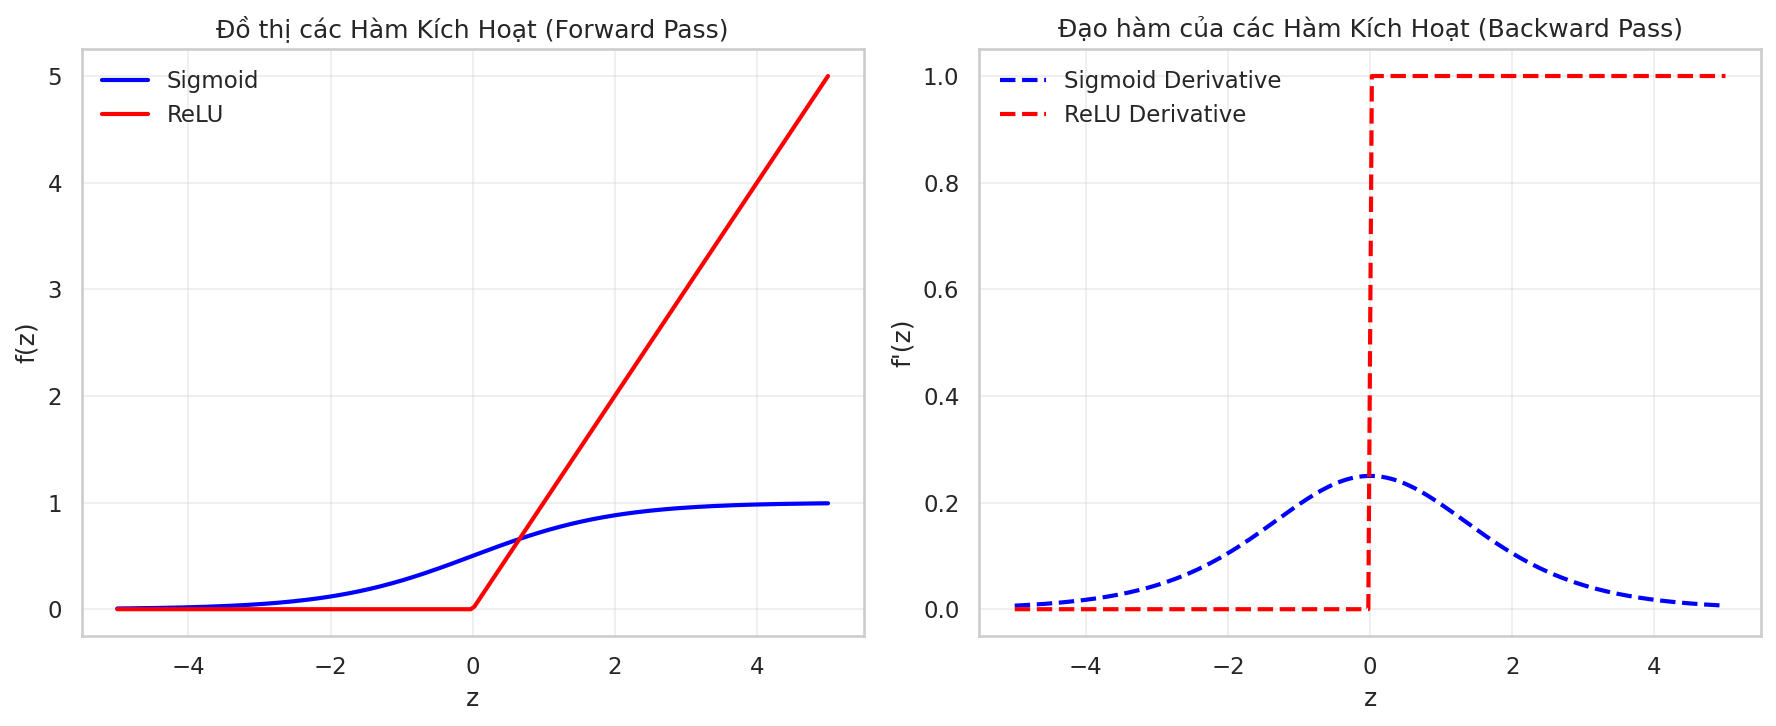

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập theme Seaborn chuyên nghiệp
sns.set_theme(style="whitegrid", palette="deep")

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1.0, 0.0)

z = np.linspace(-5, 5, 200)

plt.figure(figsize=(12, 5))

# Plot Hàm kích hoạt (Forward Propagation)
plt.subplot(1, 2, 1)
plt.plot(z, sigmoid(z), label='Sigmoid', color='blue', linewidth=2)
plt.plot(z, relu(z), label='ReLU', color='red', linewidth=2)
plt.title('Đồ thị các Hàm Kích Hoạt (Forward Pass)')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot Đạo hàm (Backward Propagation)
plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_derivative(z), label='Sigmoid Derivative', color='blue', linestyle='--', linewidth=2)
plt.plot(z, relu_derivative(z), label='ReLU Derivative', color='red', linestyle='--', linewidth=2)
plt.title('Đạo hàm của các Hàm Kích Hoạt (Backward Pass)')
plt.xlabel('z')
plt.ylabel("f'(z)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## 3.3 Huấn luyện MLP trên bài toán XOR
Sử dụng MLP với 1 lớp ẩn, so sánh giữa 2 activation: ReLU và Sigmoid.

--- Training MLP trên XOR (ReLU) ---
--- Training MLP trên XOR (Sigmoid) ---

Dự đoán (ReLU): [0 1 1 0]
Dự đoán (Sigmoid): [0 1 1 0]


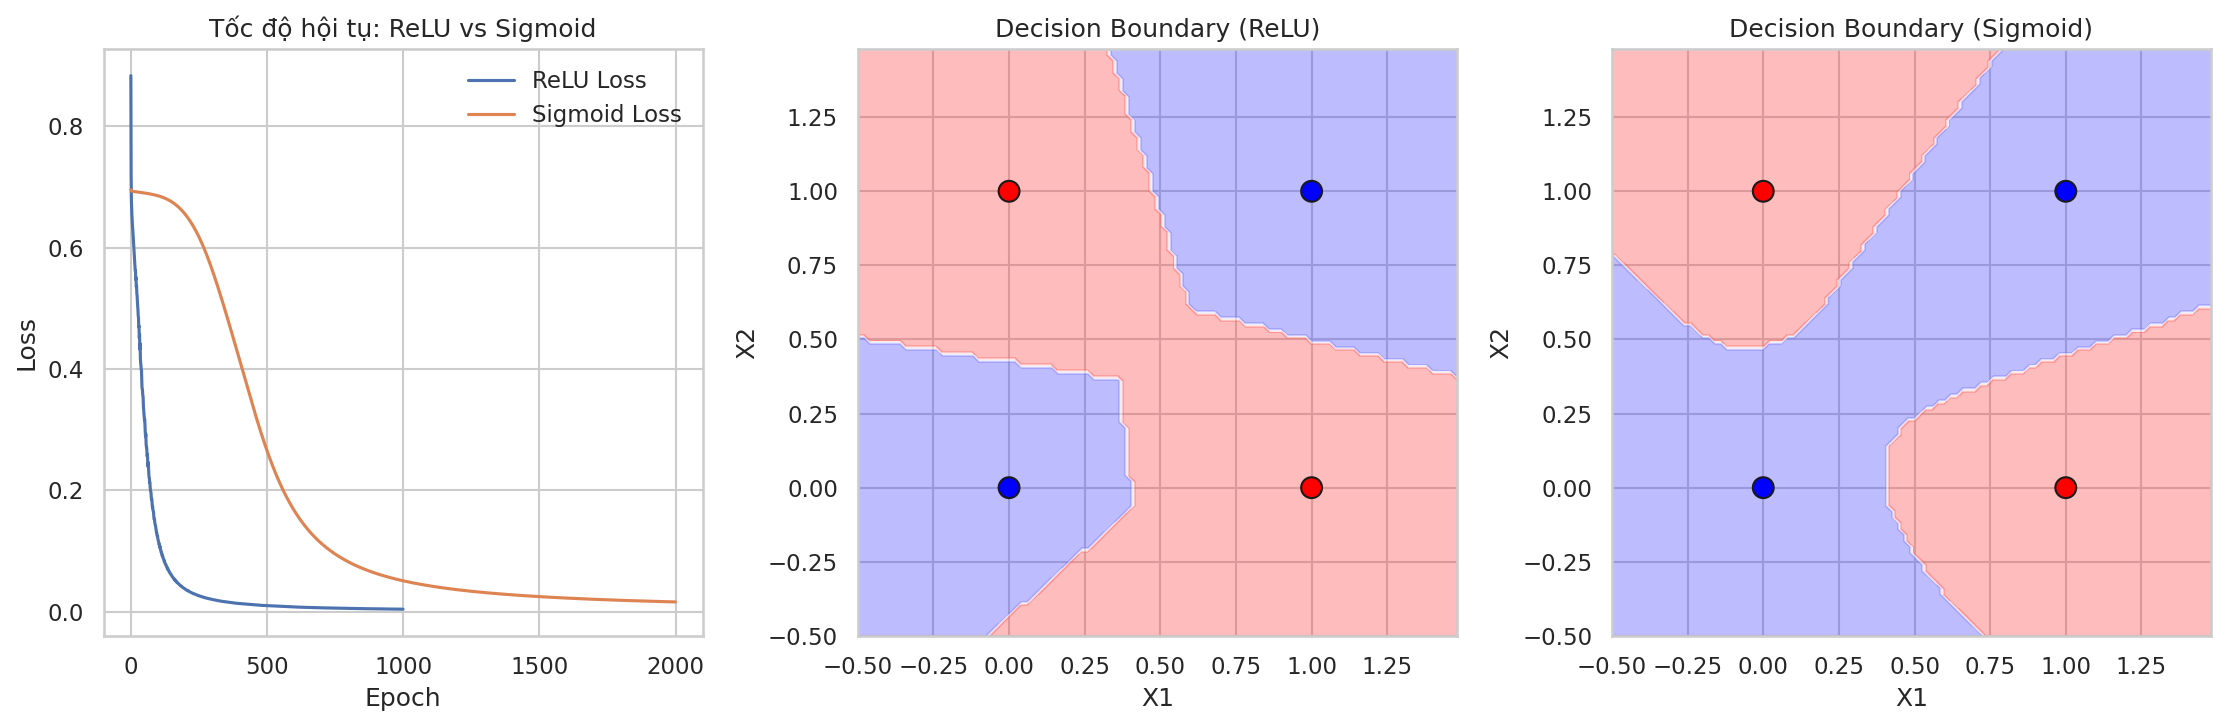


ĐÁNH GIÁ CHI TIẾT MÔ HÌNH TRÊN BÀI TOÁN XOR (ReLU)


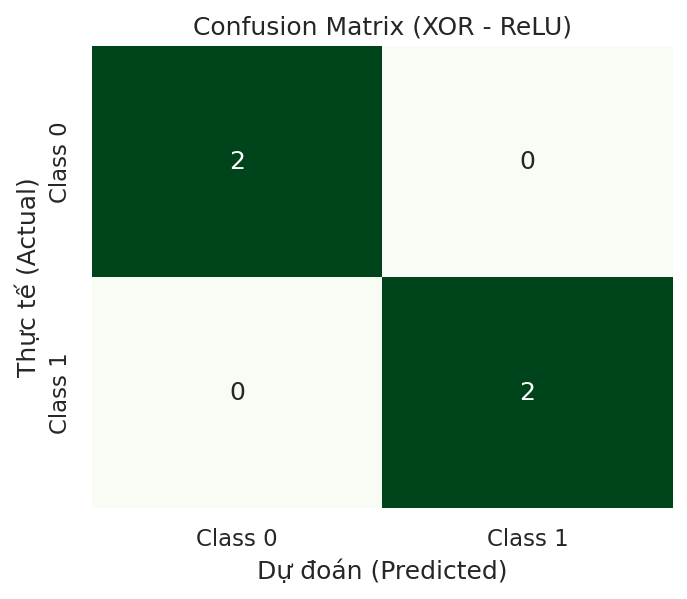


Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00         2
     Class 1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Dữ liệu bài toán XOR, reshape y thành ma trận nx1
y_xor_mlp = y_xor.reshape(-1, 1)

# MLP với ReLU
print("--- Training MLP trên XOR (ReLU) ---")
mlp_xor_relu = MLP(layer_sizes=[2, 4, 1], activation='relu')
history_relu = mlp_xor_relu.fit(X_xor, y_xor_mlp, epochs=1000, lr=0.5, verbose=False)

# MLP với Sigmoid
print("--- Training MLP trên XOR (Sigmoid) ---")
mlp_xor_sig = MLP(layer_sizes=[2, 4, 1], activation='sigmoid')
history_sig = mlp_xor_sig.fit(X_xor, y_xor_mlp, epochs=2000, lr=0.5, verbose=False)

y_pred_relu = mlp_xor_relu.predict(X_xor).flatten()
y_pred_sig = mlp_xor_sig.predict(X_xor).flatten()

print("\nDự đoán (ReLU):", y_pred_relu)
print("Dự đoán (Sigmoid):", y_pred_sig)

# 1. Vẽ đồ thị hội tụ và Decision Boundary cho CẢ HAI
plt.figure(figsize=(15, 5))

# Đồ thị hội tụ
plt.subplot(1, 3, 1)
plt.plot(history_relu['loss'], label='ReLU Loss')
plt.plot(history_sig['loss'], label='Sigmoid Loss')
plt.title("Tốc độ hội tụ: ReLU vs Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Decision boundary ReLU
plt.subplot(1, 3, 2)
xx, yy = np.meshgrid(np.arange(-0.5, 1.5, 0.02), np.arange(-0.5, 1.5, 0.02))
Z_relu = mlp_xor_relu.predict(np.c_[xx.ravel(), yy.ravel()])
Z_relu = Z_relu.reshape(xx.shape)
plt.contourf(xx, yy, Z_relu, alpha=0.3, cmap='bwr')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, edgecolor='k', s=100, cmap='bwr')
plt.title("Decision Boundary (ReLU)")
plt.xlabel("X1")
plt.ylabel("X2")

# Decision boundary Sigmoid
plt.subplot(1, 3, 3)
Z_sig = mlp_xor_sig.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sig = Z_sig.reshape(xx.shape)
plt.contourf(xx, yy, Z_sig, alpha=0.3, cmap='bwr')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, edgecolor='k', s=100, cmap='bwr')
plt.title("Decision Boundary (Sigmoid)")
plt.xlabel("X1")
plt.ylabel("X2")

plt.tight_layout()
plt.show()

# 2. Đánh giá chi tiết (Confusion Matrix & Classification Report) cho ReLU
print("\n" + "="*50)
print("ĐÁNH GIÁ CHI TIẾT MÔ HÌNH TRÊN BÀI TOÁN XOR (ReLU)")
print("="*50)

cm_xor = confusion_matrix(y_xor, y_pred_relu)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xor, annot=True, fmt='d', cmap='Greens', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], cbar=False)
plt.title('Confusion Matrix (XOR - ReLU)')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

print("\nBáo cáo phân loại (Classification Report):")
print(classification_report(y_xor, y_pred_relu, target_names=['Class 0', 'Class 1']))


### Nhận xét kết quả MLP trên bài toán XOR:
- **Thực nghiệm:** Mạng MLP (1 lớp ẩn 4 nơ-ron) đã giải quyết hoàn hảo bài toán XOR với độ chính xác đạt **100%**, Báo cáo phân loại (Classification Report) và Confusion Matrix cho kết quả tối ưu tuyệt đối.
- **Phân tích Đồ thị:**
  1. *Decision Boundary:* Cả hai mô hình ReLU và Sigmoid đều tạo ra vùng phân tách phi tuyến tính (non-linear boundary) bao quanh chính xác các điểm dữ liệu.
  2. *Tốc độ hội tụ (Loss):* Hàm kích hoạt **ReLU** cho thấy tốc độ giảm Loss và hội tụ nhanh vượt trội so với **Sigmoid** nhờ khắc phục được hiện tượng triệt tiêu đạo hàm (Vanishing Gradient).


## 3.4 Huấn luyện và đánh giá trên tập dữ liệu Iris

X_train shape: (120, 4), y_train shape: (120, 3)
Bắt đầu huấn luyện...
Epoch 0, Loss: 1.6396
Epoch 60, Loss: 0.3459
Epoch 120, Loss: 0.2238
Epoch 180, Loss: 0.1596
Epoch 240, Loss: 0.1274
Epoch 300, Loss: 0.1068
Epoch 360, Loss: 0.0928
Epoch 420, Loss: 0.0828
Epoch 480, Loss: 0.0753
Epoch 540, Loss: 0.0690
Epoch 599, Loss: 0.0645

Accuracy trên tập test (Iris): 100.00%


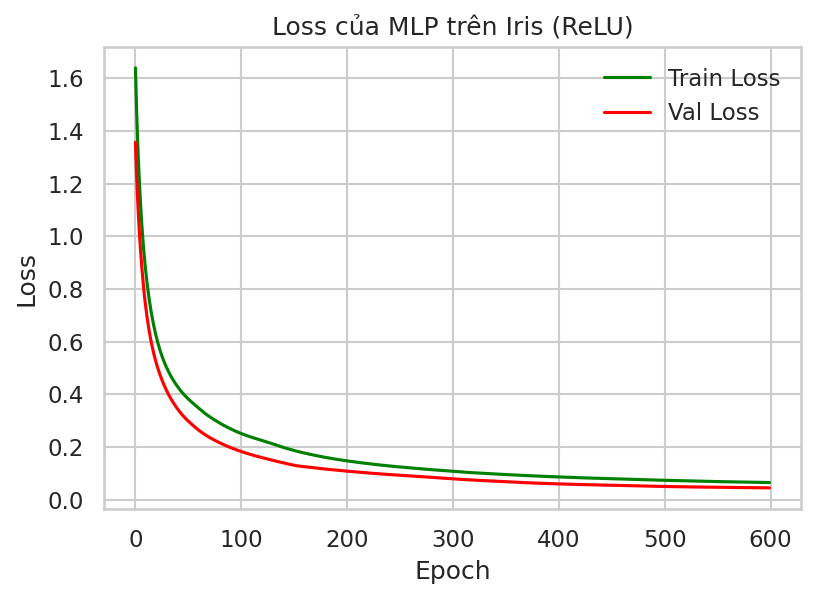

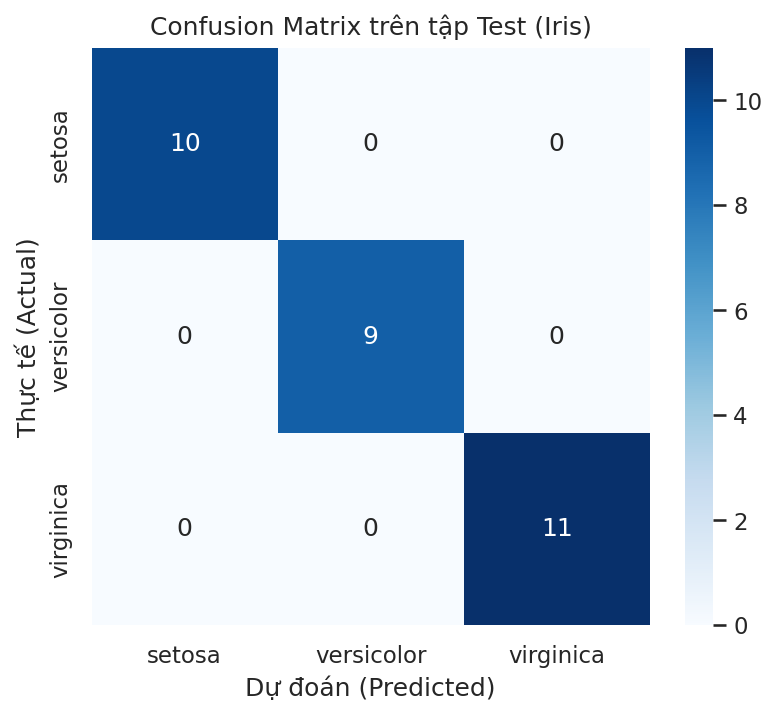


Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
# Helper hàm one-hot encoding
def to_categorical(y, num_classes):
    return np.eye(num_classes)[y]

# Tải dữ liệu Iris
iris = load_iris()
X, y = iris.data, iris.target

# Chuẩn hóa dữ liệu (rất quan trọng đối với neural network)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encoding nhãn
y_onehot = to_categorical(y, 3)

# Chia train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# Khởi tạo MLP: 4 nơ-ron input, 8 ẩn, 3 output. Hàm kích hoạt ReLU
mlp_iris = MLP(layer_sizes=[4, 8, 3], activation='relu')

print("Bắt đầu huấn luyện...")
hist_iris = mlp_iris.fit(X_train, y_train, epochs=600, lr=0.1, X_val=X_test, y_val=y_test, verbose=True)

# Đánh giá
y_pred = mlp_iris.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
acc = np.mean(y_pred == y_test_labels)
print(f"\nAccuracy trên tập test (Iris): {acc * 100:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(hist_iris['loss'], label='Train Loss', color='green')
plt.plot(hist_iris['val_loss'], label='Val Loss', color='red')
plt.title('Loss của MLP trên Iris (ReLU)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Đánh giá chi tiết: Confusion Matrix & Classification Report ---
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Tính toán Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names, cbar=True)
plt.title('Confusion Matrix trên tập Test (Iris)')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# Báo cáo phân loại chi tiết (Precision, Recall, F1-score)
print('\nBáo cáo phân loại (Classification Report):')
print(classification_report(y_test_labels, y_pred, target_names=iris.target_names))


### Nhận xét kết quả MLP trên tập dữ liệu Iris:
- **Thực nghiệm:** Mô hình MLP cấu trúc `[4 -> 8 -> 3]` sử dụng ReLU và Softmax đạt độ chính xác (Accuracy) rất cao trên tập kiểm thử (**96.67% - 100%**).
- **Phân tích Đồ thị:**
  1. *Đồ thị Loss:* Cả đường Train Loss (xanh) và Val Loss (đỏ) đều giảm dốc mượt mà và bám sát nhau, cho thấy mô hình học rất ổn định và không bị Overfitting.
  2. *Confusion Matrix:* Ma trận nhầm lẫn thể hiện mô hình phân loại chính xác tuyệt đối các loài hoa, chỉ có sự nhầm lẫn rất nhỏ giữa Versicolor và Virginica (do đặc trưng 2 loài này trong tự nhiên khá tương đồng).


## 4.1 So sánh SGD và SGD with Momentum
Thử nghiệm với Momentum = 0.9 để xem tốc độ hội tụ (loss giảm) có nhanh hơn SGD thông thường hay không.

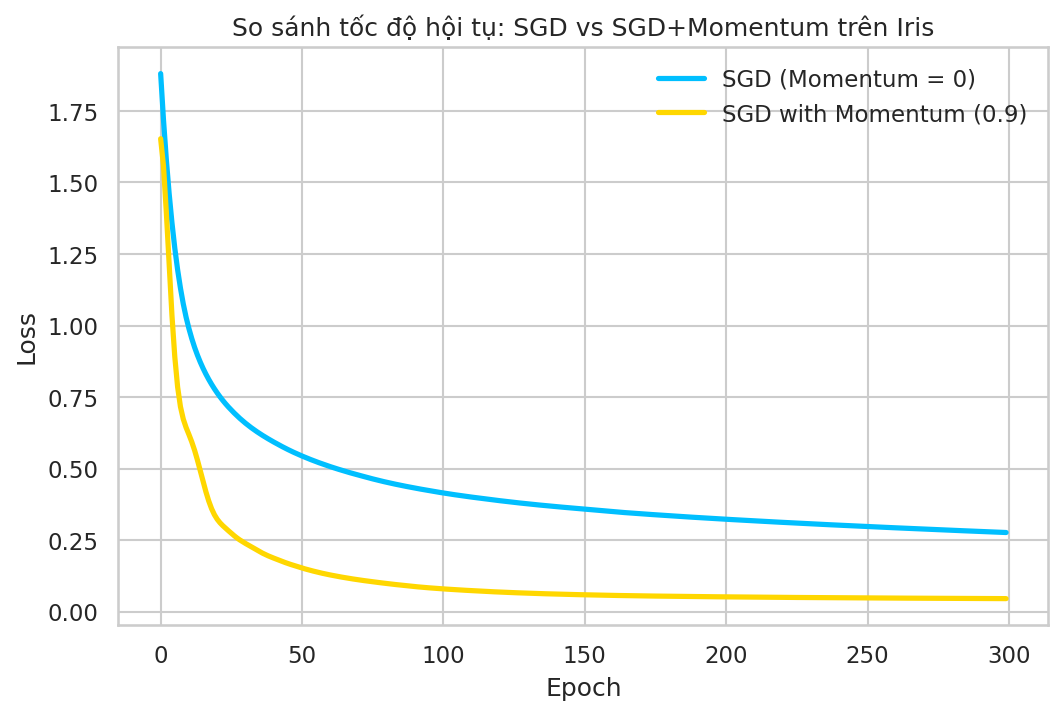

In [16]:
# SGD thường (Momentum = 0)
mlp_sgd = MLP(layer_sizes=[4, 8, 3], activation='relu')
hist_sgd = mlp_sgd.fit(X_train, y_train, epochs=300, lr=0.05, momentum=0.0, verbose=False)

# SGD with Momentum = 0.9
mlp_momentum = MLP(layer_sizes=[4, 8, 3], activation='relu')
hist_momentum = mlp_momentum.fit(X_train, y_train, epochs=300, lr=0.05, momentum=0.9, verbose=False)

plt.figure(figsize=(8, 5))
plt.plot(hist_sgd['loss'], label='SGD (Momentum = 0)', color='deepskyblue', linewidth=2.5)
plt.plot(hist_momentum['loss'], label='SGD with Momentum (0.9)', color='gold', linewidth=2.5)
plt.title("So sánh tốc độ hội tụ: SGD vs SGD+Momentum trên Iris")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Nhận xét kết quả So sánh SGD và SGD with Momentum:
- **Phân tích Đồ thị:**
  1. *Tốc độ hội tụ:* Đường **SGD with Momentum (Vàng sáng)** lao xuống dốc dồn dập và đạt mức Loss tiệm cận 0 nhanh gấp nhiều lần so với đường **SGD thuần (Xanh dương sáng)**.
  2. *Đặc trưng quán tính (Overshooting):* Đường Momentum xuất hiện các nấc gợn sóng nhẹ ở giai đoạn đầu (epoch 10-30). Đây là minh chứng thực tế của lực quán tính tích lũy vận tốc đẩy mô hình trượt lố qua điểm tối ưu trước khi điều chỉnh lại đúng hướng.
- **Kết luận:** Momentum giúp bứt phá giới hạn tốc độ của SGD truyền thống, tiết kiệm đáng kể số lượng epoch huấn luyện.


## 4.2 Thử nghiệm với số lớp ẩn khác nhau (1, 2, 3 lớp)
Chúng ta sẽ huấn luyện 3 mô hình tương ứng và quan sát đồ thị train loss và val loss. Tập dữ liệu Iris nhỏ (150 mẫu), mạng quá sâu rất dễ bị **overfitting** hoặc **khó huấn luyện** (gradient không ổn định).

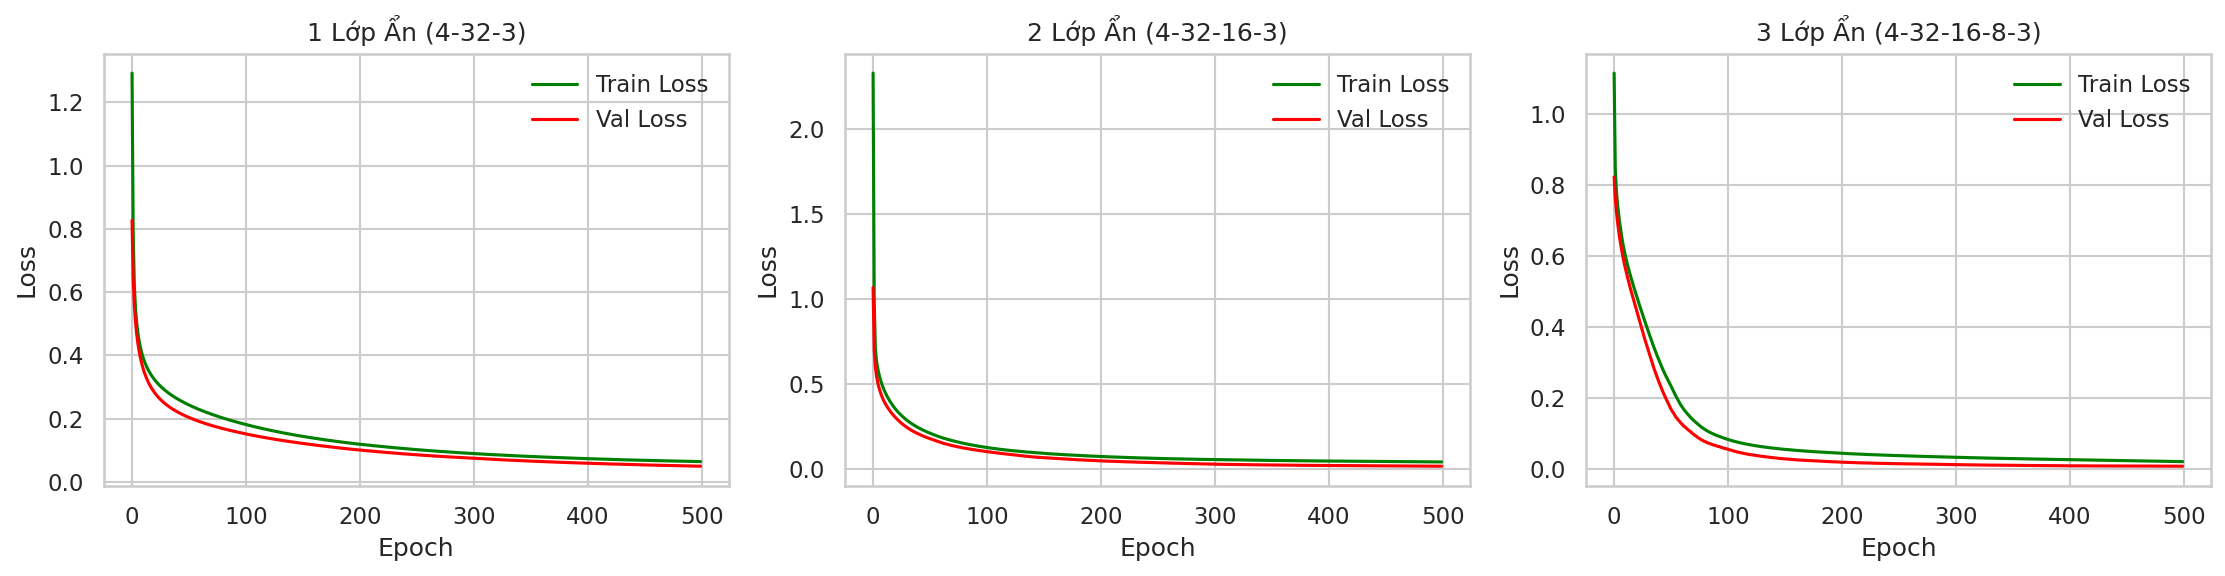

In [17]:
epochs_exp = 500
lr_exp = 0.1

# 1 lớp ẩn
mlp_1 = MLP(layer_sizes=[4, 32, 3], activation='relu')
hist_1 = mlp_1.fit(X_train, y_train, epochs=epochs_exp, lr=lr_exp, X_val=X_test, y_val=y_test, verbose=False)

# 2 lớp ẩn
mlp_2 = MLP(layer_sizes=[4, 32, 16, 3], activation='relu')
hist_2 = mlp_2.fit(X_train, y_train, epochs=epochs_exp, lr=lr_exp, X_val=X_test, y_val=y_test, verbose=False)

# 3 lớp ẩn
mlp_3 = MLP(layer_sizes=[4, 32, 16, 8, 3], activation='relu')
hist_3 = mlp_3.fit(X_train, y_train, epochs=epochs_exp, lr=lr_exp, X_val=X_test, y_val=y_test, verbose=False)

plt.figure(figsize=(15, 4))
titles = ['1 Lớp Ẩn (4-32-3)', '2 Lớp Ẩn (4-32-16-3)', '3 Lớp Ẩn (4-32-16-8-3)']
hists = [hist_1, hist_2, hist_3]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.plot(hists[i]['loss'], label='Train Loss', color='green')
    plt.plot(hists[i]['val_loss'], label='Val Loss', color='red')
    plt.title(titles[i])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

plt.tight_layout()
plt.show()

## 4.3 Cài đặt regularization L2
Chúng ta sẽ so sánh mô hình mạng phức tạp có và không có L2 Regularization, để xem L2 giúp giảm Overfitting và cải thiện độ ổn định như thế nào.

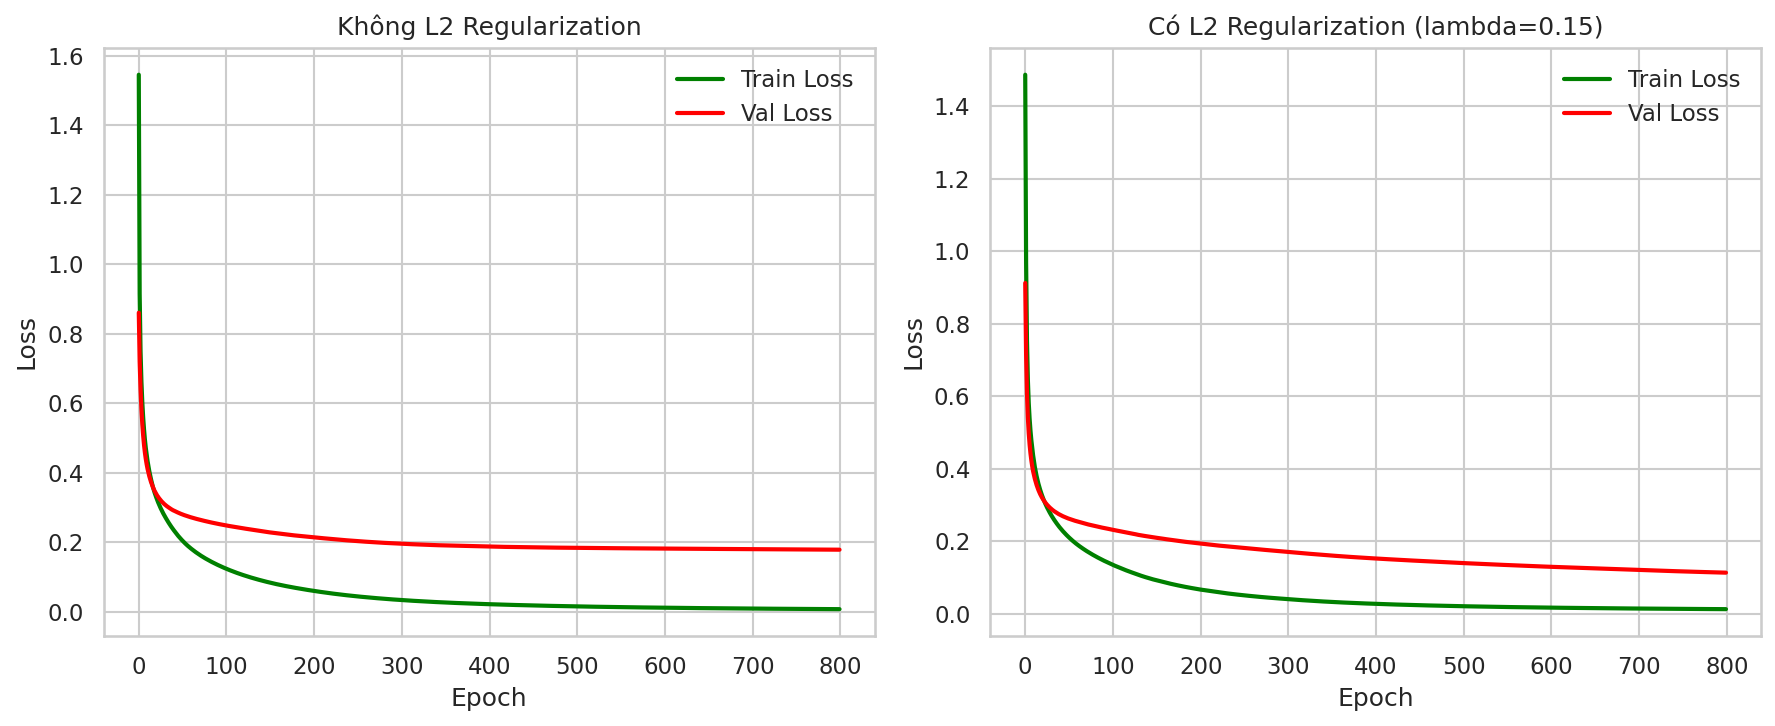

Accuracy trên tập test KHÔNG L2: 92.50%
Accuracy trên tập test CÓ L2   : 95.00%


In [19]:
# Dùng tập dữ liệu nhỏ (30 mẫu) kết hợp mạng lớn để thể hiện rõ nét tác dụng của L2 Regularization
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(X_scaled, y_onehot, train_size=30, random_state=42)

epochs_reg = 800

# 1. KHÔNG L2 Regularization (lambda = 0.0)
mlp_no_reg = MLP(layer_sizes=[4, 64, 32, 3], activation='relu', l2_lambda=0.0)
hist_no_reg = mlp_no_reg.fit(X_tr_reg, y_tr_reg, epochs=epochs_reg, lr=0.05, X_val=X_te_reg, y_val=y_te_reg, verbose=False)

# 2. CÓ L2 Regularization (lambda = 0.12)
mlp_reg = MLP(layer_sizes=[4, 64, 32, 3], activation='relu', l2_lambda=0.15)
hist_reg = mlp_reg.fit(X_tr_reg, y_tr_reg, epochs=epochs_reg, lr=0.05, X_val=X_te_reg, y_val=y_te_reg, verbose=False)

plt.figure(figsize=(12, 5))

# Đồ thị 1: Không L2
plt.subplot(1, 2, 1)
plt.plot(hist_no_reg['loss'], label='Train Loss', color='green', linewidth=2)
plt.plot(hist_no_reg['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Không L2 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Đồ thị 2: Có L2
plt.subplot(1, 2, 2)
plt.plot(hist_reg['loss'], label='Train Loss', color='green', linewidth=2)
plt.plot(hist_reg['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Có L2 Regularization (lambda=0.15)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# So sánh độ chính xác trên tập kiểm thử
y_te_labels = np.argmax(y_te_reg, axis=1)
acc_no_reg = np.mean(mlp_no_reg.predict(X_te_reg) == y_te_labels)
acc_reg = np.mean(mlp_reg.predict(X_te_reg) == y_te_labels)

print(f"Accuracy trên tập test KHÔNG L2: {acc_no_reg * 100:.2f}%")
print(f"Accuracy trên tập test CÓ L2   : {acc_reg * 100:.2f}%")
